# 04 — Real data: NGC 5102 HST/STIS galactic center

This notebook fits a spectrum of NGC 5102 from the Hubble Space Telescope using the
STIS spectrograph (G750L grating).  The STIS data has higher spatial resolution than
MUSE (~0.1 arcsec per pixel vs ~0.2 arcsec), which probes kinematics at smaller radii.

The spectrum used here (`bin0105sp.spec`) is the single pixel/spaxel centered on the
galactic center, extracted using the same binning scheme as the SCO framework (not
Voronoi binning) -- the same central bin used for the MUSE data in notebook 03.  The
data is bundled in `examples/data/stis/`.

**Key differences from the MUSE notebook:**
- Shorter wavelength range (8275 – 8846 Å, step = 0.5586 Å/pixel)
- The file's error column is a placeholder, not real per-pixel errors — we override
  it with a uniform S/N-based estimate (`gal_errors=flux/50`), same approach as the
  MUSE notebook, rather than using `use_spectrum_errors=True`
- Templates are CaT stellar library scans (Cenarro et al. 2001)
- `wavemin_full` and `step` must be provided because the spectrum file uses integer pixel indices

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

from kinextract import FitConfig, run_spectral_fit, set_verbose

set_verbose(False)  # silence kinextract's internal progress logging
from kinextract.fitting import fit_losvd_gauss_hermite


# Path to bundled example data (adjust if running from a different location)
DATA_DIR = Path('..') / 'data'
STIS_DIR = DATA_DIR / 'stis'

# ── To use a different spectrum, change this line ────────────────────────────
SPEC_FILE = STIS_DIR / 'bin0105sp.spec'

## 1. Load and inspect the spectrum

In [2]:
# ── STIS wavelength grid ──────────────────────────────────────────────────────
# The .spec file contains integer pixel indices (1–1024); kinextract reconstructs
# wavelengths as: wave = wavemin_full + (pix - 1) * step
WAVEMIN_FULL = 8275.0       # Å, pixel 1
STEP         = 0.5586       # Å / pixel  (mean STIS G750L dispersion)
N_PIX        = 1024
wavelength   = WAVEMIN_FULL + np.arange(N_PIX) * STEP   # observed frame

data = np.loadtxt(SPEC_FILE)
pix, flux = data[:, 0].astype(int), data[:, 1]

# This STIS spectrum just has placeholder error values, 
# so we can use a simple S/N estimate to set the errors instead
snr = 50.0
ferr = (flux / snr) + 1e-3  # counts, avoid zero error

print(f"Spectrum pixels: {len(flux)}")
print(f"Flux range:  {flux.min():.0f} - {flux.max():.0f}  counts")
print(f"Error range: {ferr.min():.0f} - {ferr.max():.0f}  counts")
print(f"Median S/N per pixel: {np.median(flux / ferr):.1f}")

Spectrum pixels: 1024
Flux range:  0 - 12996374  counts
Error range: 0 - 259927  counts
Median S/N per pixel: 50.0


## 2. Quick-look plot

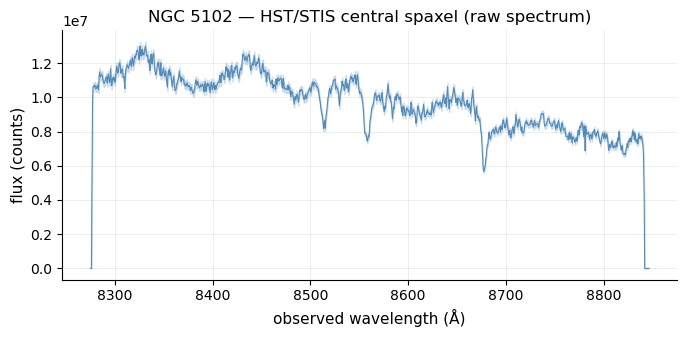

In [3]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(wavelength, flux, lw=0.8, color='steelblue', alpha=0.9)
ax.fill_between(wavelength, flux - ferr, flux + ferr, color='steelblue', alpha=0.2)
ax.set_xlabel('observed wavelength (Å)')
ax.set_ylabel('flux (counts)')
ax.set_title('NGC 5102 — HST/STIS central spaxel (raw spectrum)')
plt.tight_layout()
plt.show()

## 3. FitConfig for STIS

Because column 0 of the `.spec` file contains integer pixel indices, kinextract
needs `wavemin_full` and `step` to reconstruct the wavelength axis.

The file's own error column is just a placeholder, so we pass the S/N-based `ferr`
computed above directly via `gal_errors=` (overriding the file column) and set
`use_spectrum_errors=False` since we're not using the file's errors either way.

`fit_continuum=True` co-fits a penalized-B-spline continuum directly into the same
optimization as the LOSVD and template weights (see `kinextract.joint`). Note:
continuum-cofit fits like this one don't yet support
`LOSVDErrorEstimator.laplace_covariance`/`bias_correction` (see Section 7) -- only
`residual_bootstrap`.

In [4]:

cfg = FitConfig(
    template_list_file    = str(STIS_DIR / 'Tlist'),
    template_dir          = str(STIS_DIR),
    # outdir="./my_output_dir", write_outputs=True,  # uncomment to save .fit/.temp/.ascii/.rms output files
    wavemin_full          = WAVEMIN_FULL,  # Å, minimum wavelength of full spectrum (pixel 1)
    step                  = STEP,          # Å / pixel
    wavefitmin            = 8400.0,        # Å  (rest-frame; kinextract applies zgal)
    wavefitmax            = 8750.0,        # Å
    zgal                  = 0.001556,      # redshift estimate from NED (heliocentric)
    losvd_vmin            = -300.0,        # km/s
    losvd_vmax            = +300.0,        # km/s
    fit_continuum         = True,
    use_spectrum_errors   = False,         # per-pixel errors not available
    xlam_auto             = True,          # xlam_criterion defaults to 'discrepancy' (Cappellari/pPXF-style); see FitConfig docstring
    sigl                  = 100.0,
    clean                 = True,
    clean_ca_half_width   = 8.0,
    map_maxiter           = 2000,
    print_every           = 10000,
)
print("FitConfig ready.")

FitConfig ready.


## 4. Run the fit

In [5]:
# Initial fit with the S/N-based error guess from above, then one
# error-rescaling pass: per-pixel errors this simple are a placeholder, not
# a validated noise model, so we calibrate their overall scale against the
# fit itself (rescale by sqrt(chi2_red), refit) -- standard practice for
# LOSVD fitting, rather than reporting chi2_red far from 1 at face value.
fit = run_spectral_fit(cfg, gal_file=str(SPEC_FILE), gal_errors=ferr)
scale = float(np.sqrt(fit['outputs']['chi2_red']))
ferr = ferr * scale
print(f"Error rescaling: chi2_red={fit['outputs']['chi2_red']:.3f} -> scale factor {scale:.3f} -> refitting")

fit = run_spectral_fit(cfg, gal_file=str(SPEC_FILE), gal_errors=ferr)
st  = fit['state']
out = fit['outputs']
b   = out['b']
gp  = out['gp']
print(f"chi2_red = {out['chi2_red']:.3f}  (after error rescaling)")
print(f"xlam used = {st.xlam}")
print(f"success     : {fit['result'].success}")
if not fit['result'].success:
    print(f"  WARNING: L-BFGS-B did not converge ({fit['result'].message}) -- treat "
          "V/sigma/h3/h4 as unreliable; consider raising map_maxiter or loosening map_ftol.")

Error rescaling: chi2_red=2.619 -> scale factor 1.618 -> refitting


chi2_red = 0.986  (after error rescaling)
xlam used = 1843.4229924091105
success     : True


In [6]:
from IPython.display import display, Math

display(Math(fr"\chi^2_{{\rm red}} = {out['chi2_red']:.3f}"))

<IPython.core.display.Math object>

## 5. Gauss-Hermite moments

In [7]:
gh = fit_losvd_gauss_hermite(st.xl, b, fit_h3h4=True)
print(f"V  = {gh['vherm']:+.1f} km/s")
print(f"σ  = {gh['sherm']:.1f} km/s")
print(f"h3 = {gh['h3']:+.4f}")
print(f"h4 = {gh['h4']:+.4f}")

V  = +21.1 km/s
σ  = 82.4 km/s
h3 = +0.1405
h4 = +0.1021


## 6. Results plots

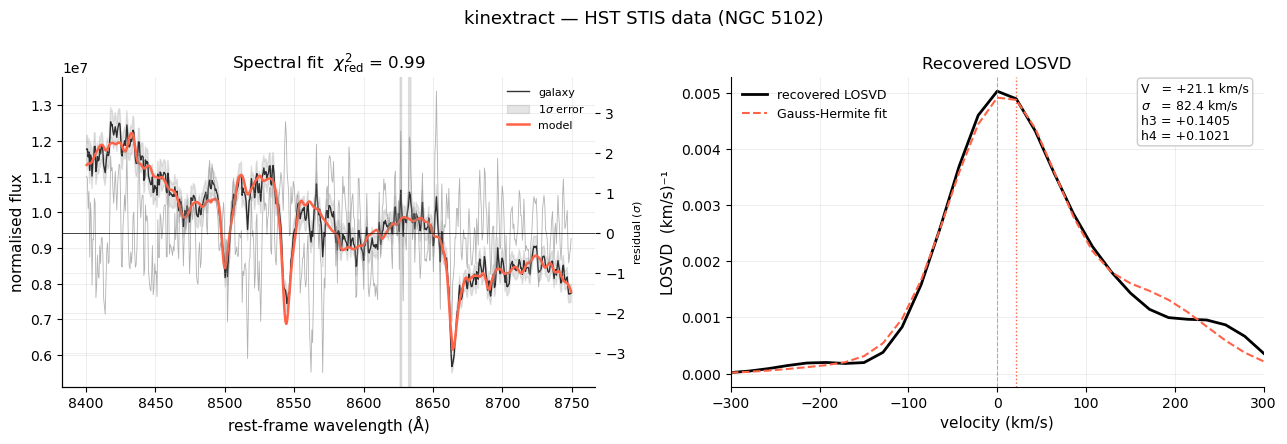

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('kinextract — HST STIS data (NGC 5102)', fontsize=13)

# ── Panel 1: spectral fit ─────────────────────────────────────────────────────
ax = axes[0]
ax.plot(st.x, st.g,  lw=1.0, color='black', label='galaxy', alpha=0.8)
ax.fill_between(st.x, st.g - st.gerr, st.g + st.gerr, alpha=0.20, color='gray', label=r'$1\sigma$ error')
ax.plot(st.x, gp, lw=1.8, color='tomato', label='model', zorder=3)
resid = (st.g - gp) / np.nanmedian(st.gerr[st.gerr < 1e9])
ax.set_ylim(0.9*st.g.min(), 1.1*st.g.max())
ax2 = ax.twinx()
ax2.plot(st.x, resid, lw=0.6, color='grey', alpha=0.6)
ax2.axhline(0, lw=0.5, color='k')
ax2.set_ylabel(r'residual ($\sigma$)', fontsize=8)
ax.set_xlabel('rest-frame wavelength (Å)')
ax.set_ylabel('normalised flux')
ax.set_title(r'Spectral fit  $\chi^2_{\rm red}$ = ' + f"{out['chi2_red']:.2f}")
ax.legend(fontsize=8, framealpha=1.0, facecolor='white').set_zorder(20)

# ── Panel 2: LOSVD ────────────────────────────────────────────────────────────
ax = axes[1]
b_norm = b / trapezoid(b, st.xl)
ax.plot(st.xl, b_norm, lw=2.0, color='black', label='recovered LOSVD')
ax.plot(st.xl, gh['model']/trapezoid(gh['model'], st.xl), lw=1.5, color='tomato', ls='--', label='Gauss-Hermite fit')
ax.axvline(gh['vherm'], lw=1.0, color='tomato', ls=':')
ax.axvline(0,           lw=0.8, color='grey',   ls='--', alpha=0.6)
ax.text(0.77, 0.79,
        f"V   = {gh['vherm']:+.1f} km/s\n"
        fr"$\sigma$" + f"   = {gh['sherm']:.1f} km/s\n"
        f"h3 = {gh['h3']:+.4f}\n"
        f"h4 = {gh['h4']:+.4f}",
        transform=ax.transAxes, fontsize=9, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))
ax.set_xlabel('velocity (km/s)')
ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title('Recovered LOSVD')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()

## 7. Error estimation

Uncertainty on the LOSVD is estimated via **residual bootstrap**: resample fit residuals into synthetic spectra and refit each through the same pipeline (here, `kinextract.joint`, at the main fit's own converged xlam/sigl0/v_center) -> an independent, frequentist estimate of the LOSVD's scatter. Slower than a closed-form approximation since each of `N_BOOT` replicates is a full refit, but the only supported method for continuum-cofit fits: `laplace_covariance`/`bias_correction` don't yet understand the joint method's parameter layout and raise `NotImplementedError`.

In [9]:
from kinextract import LOSVDErrorEstimator

N_BOOT = 50   # increase to ≥200 for publication

est     = LOSVDErrorEstimator(fit, cfg)
boot    = est.residual_bootstrap(n_bootstrap=N_BOOT, n_jobs=1)
summary = est.summarize(bootstrap_result=boot)

gh_map = summary['gh_map']
gh_err = summary.get('gh_err_recommended', {})
print("Bootstrap uncertainties:")
for label, mkey, ekey in [('V', 'vherm', 'gh_vherm'), ('σ', 'sherm', 'gh_sherm'),
                           ('h3', 'h3', 'gh_h3'), ('h4', 'h4', 'gh_h4')]:
    val = gh_map.get(mkey)
    err = gh_err.get(ekey)
    if val is not None:
        err_str = f' ± {err:.2f}' if err is not None else ''
        unit = ' km/s' if label in ('V', 'σ') else ''
        print(f'  {label:5s} = {val:+.2f}{unit}{err_str}')

[LOSVDErrors] Starting residual bootstrap (n=50, block=1, jobs=1)...


[LOSVDErrors] Bootstrap 5/50 (1s elapsed)


[LOSVDErrors] Bootstrap 10/50 (3s elapsed)


[LOSVDErrors] Bootstrap 15/50 (4s elapsed)


[LOSVDErrors] Bootstrap 20/50 (6s elapsed)


...

[LOSVDErrors] Bootstrap 30/50 (9s elapsed)


[LOSVDErrors] Bootstrap 35/50 (10s elapsed)


[LOSVDErrors] Bootstrap 40/50 (12s elapsed)


[LOSVDErrors] Bootstrap 45/50 (13s elapsed)


[LOSVDErrors] Bootstrap 50/50 (15s elapsed)
[LOSVDErrors] Bootstrap done in 14.7s. Success: 50/50

LOSVD ERROR SUMMARY
  Gauss-Hermite moments (MAP, consistent with pallmc.f):
    V    = +21.13 km/s ± 2.60
    σ    = 82.42 km/s ± 3.77
    h3   = +0.1405 ± 0.0296
    h4   = +0.1021 ± 0.0274
  LOSVD moments (for reference):
    V    = +40.10 km/s ± 4.57
    σ    = 99.18 km/s ± 3.78

  Bootstrap: 50 successful / 50 total replicates

Bootstrap uncertainties:
  V     = +21.13 km/s ± 2.60
  σ     = +82.42 km/s ± 3.77
  h3    = +0.14 ± 0.03
  h4    = +0.10 ± 0.03


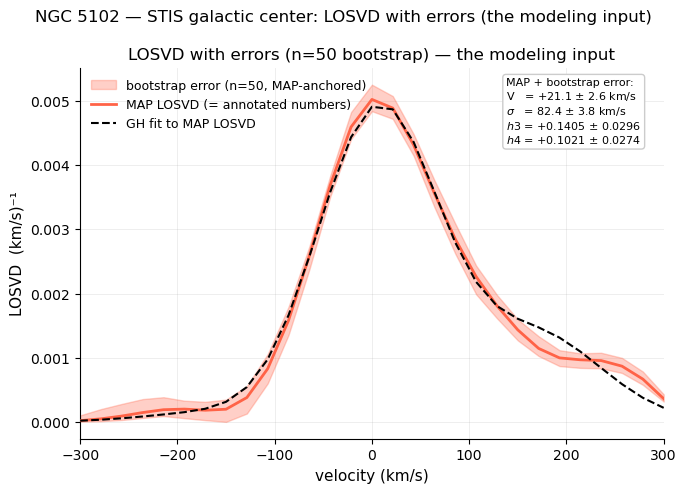

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('NGC 5102 — STIS galactic center: LOSVD with errors (the modeling input)', fontsize=12)

b_trap   = trapezoid(b, st.xl)
b_norm   = b / b_trap

# Error bounds are MAP-anchored (summary['b_lo_recommended']/['b_hi_recommended']),
# matching the legacy pipeline's actual modeling-input convention: traced
# directly through mcfitw.f -> pallmc.f's .mcfit2 section -> transvd -> the
# final *_in files the Schwarzschild-modeling stage reads. .mcfit2 uses the
# bootstrap ensemble's biweight location only to measure how far the
# 16th/84th percentiles sit from it, then transplants that *distance* onto
# the MAP fit's own value -- never onto the ensemble's own location (see
# errors.py's _map_anchored_bounds). So this curve -- MAP LOSVD, plus these
# MAP-anchored bounds -- is the *_in-equivalent LOSVD-with-errors: what
# actually corresponds to what goes into modeling. There is no separate
# "bootstrap median" curve to show; the ensemble is only ever used for its
# spread, never as an alternative central estimate.
b_lo = summary['b_lo_recommended'] / b_trap
b_hi = summary['b_hi_recommended'] / b_trap

gh_med = summary['gh_center_recommended']
gh_model_norm = gh_med['model'] / trapezoid(gh_med['model'], st.xl)

ax.fill_between(st.xl, b_lo, b_hi, alpha=0.30, color='tomato',
                label=f'bootstrap error (n={N_BOOT}, MAP-anchored)')
ax.plot(st.xl, b_norm, lw=2.0, color='tomato', zorder=5, label='MAP LOSVD (= annotated numbers)')
ax.plot(st.xl, gh_model_norm, lw=1.5, ls='--', color='black', zorder=6, label='GH fit to MAP LOSVD')

ax.text(0.73, 0.79,
        f"MAP + bootstrap error:\n"
        fr"V   = {gh_med['vherm']:+.1f} $\pm$ {gh_err.get('gh_vherm', float('nan')):.1f}" + " km/s\n"
        fr"$\sigma$   = {gh_med['sherm']:.1f} $\pm$ {gh_err.get('gh_sherm', float('nan')):.1f}" + " km/s\n"
        fr"$h3$ = {gh_med['h3']:+.4f} $\pm$ {gh_err.get('gh_h3', float('nan')):.4f}" + "\n"
        fr"$h4$ = {gh_med['h4']:+.4f} $\pm$ {gh_err.get('gh_h4', float('nan')):.4f}",
        transform=ax.transAxes, fontsize=8, ha='left', va='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=1.0, edgecolor='0.8'))

ax.set_xlabel('velocity (km/s)'); ax.set_ylabel('LOSVD  (km/s)⁻¹')
ax.set_title(f'LOSVD with errors (n={N_BOOT} bootstrap) — the modeling input')
ax.legend(fontsize=9, loc='upper left', framealpha=1.0, facecolor='white').set_zorder(20)
ax.set_xlim(cfg.losvd_vmin, cfg.losvd_vmax)

plt.tight_layout()
plt.show()